In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [2]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset
!unzip -q dog-and-cat-classification-dataset.zip -d dog_cat_dataset


Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
 96% 747M/775M [00:03<00:00, 143MB/s]
100% 775M/775M [00:03<00:00, 205MB/s]


In [3]:
!ls dog_cat_dataset


PetImages


In [4]:
!pip install tensorflow

In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os
import matplotlib.pyplot as plt


In [7]:

base_dir = './dog_cat_dataset/PetImages'
train_cats_dir = os.path.join(base_dir, 'Cat')
train_dogs_dir = os.path.join(base_dir, 'Dog')

print("Base directory exists:", os.path.exists(base_dir))
print("Cats directory exists:", os.path.exists(train_cats_dir))
print("Dogs directory exists:", os.path.exists(train_dogs_dir))



Base directory exists: True
Cats directory exists: True
Dogs directory exists: True


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [9]:
val_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split=0.2
)

In [10]:
image_size = (64,64)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    seed = 42
)

validation_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [14]:
model = Sequential([

        Conv2D(32, kernel_size=(3, 3), padding = 'valid' , activation='relu', input_shape=(64,64, 3)),
        MaxPooling2D(pool_size=(2,2) , strides = 2),

        Conv2D(64, kernel_size=(3, 3), padding = 'valid' , activation='relu'),
        MaxPooling2D(pool_size=(2,2) , strides = 2),

        Conv2D(128, kernel_size=(3, 3), padding = 'valid' , activation='relu'),
        MaxPooling2D(pool_size=(2,2) , strides = 2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')

])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    verbose = 1
)

Epoch 1/10
193/625 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.6731 - loss: 0.5985

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.6725 - loss: 0.6018 - val_accuracy: 0.6915 - val_loss: 0.5803
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.7038 - loss: 0.5749 - val_accuracy: 0.7738 - val_loss: 0.4798
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.7298 - loss: 0.5365 - val_accuracy: 0.7835 - val_loss: 0.4614
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7437 - loss: 0.5227 - val_accuracy: 0.7802 - val_loss: 0.4611
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.7561 - loss: 0.5069 - val_accuracy: 0.7883 - val_loss: 0.4455
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.7608 - loss: 0.4920 - val_accuracy: 0.8151 - val_loss: 0.4039
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 100ms/step - accuracy: 0.7671 - loss: 0.4797 - val_accuracy: 0.8251 - val_loss: 0.3941
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.7864 - loss: 0.4535 - val_a

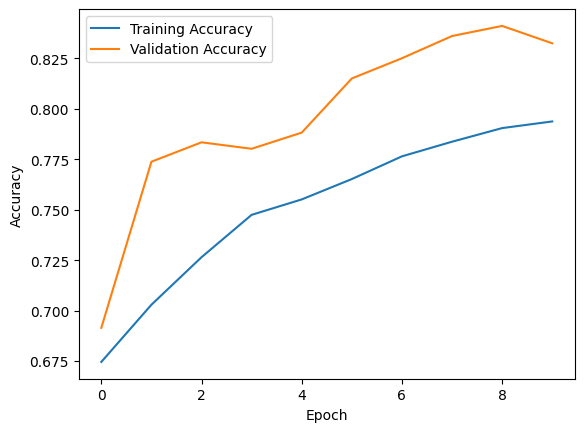

In [18]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

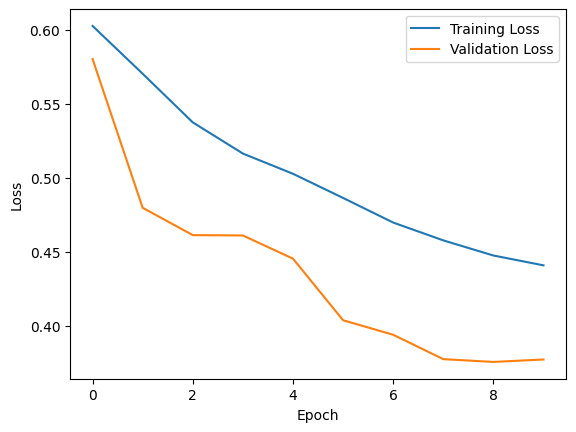

In [19]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
model.save('dog_cat_classifier.keras')

In [26]:
import cv2

In [27]:
test_img = cv2.imread('/content/dog.jpeg')
test_img = cv2.resize(test_img, (64, 64))
test_img = test_img.reshape(1, 64, 64, 3)

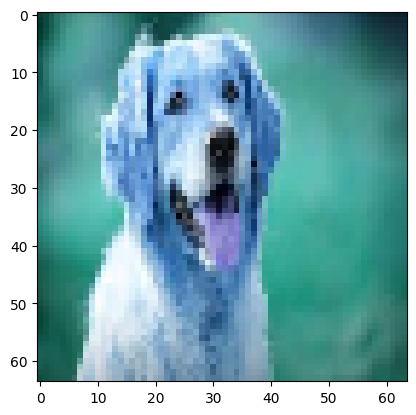

In [35]:
plt.imshow(test_img[0])

In [61]:
cat = cv2.imread('/content/dog_cat_dataset/PetImages/Cat/10.jpg')

In [62]:
cat = cv2.resize(cat, (64, 64))
cat = cat.reshape(1, 64, 64, 3)

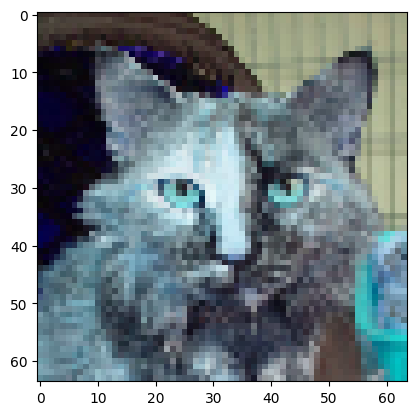

In [63]:
plt.imshow(cat[0])

In [64]:
train_generator.class_indices

{'Cat': 0, 'Dog': 1}

In [80]:
def predict_image(model, img_path):
    from tensorflow.keras.preprocessing import image
    import numpy as np

    img = image.load_img(img_path, target_size=(64,64))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        return f"Dog"
    else:
        return f"Cat"

In [81]:
result = predict_image(model , '/content/cat.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [82]:
result

'Cat'

In [83]:
result = predict_image(model , '/content/dog.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [84]:
result

'Dog'